**INTEGRANTES:**

Enzo Ambrosio da Costa - 24008773

João Vitor Guedes del Ducca - 24012015

Thomaz Pinheiro Dacorso - 24012310

Victor Manhais França - 24010801

Vitor Riki Araujo Furuta - 24008775

In [645]:
import kagglehub
import pandas as pd  # nao vai usar :(
import numpy as np
from scipy.spatial.distance import cdist
import pyspark.pandas as ps
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, coalesce, lower, regexp_replace, trim, when, length, upper, log1p, udf
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px

In [646]:
spark = SparkSession.builder.appName("roblox_games_data_analisys").getOrCreate()

In [647]:
spark.conf.set("spark.sql.ansi.enabled", False)

# Leitura dataset

## Carregar datasets


In [648]:
'''
roblox-games-data - 1/22/2022 to 5/2/2022 *outdated???

info: Date,Active Users,Favorites,Total Visits,Date Created,Last Updated,Server Size,Genre,Title

# Download latest version
roblox_games_data_path = kagglehub.dataset_download("databitio/roblox-games-data")

print("Path to dataset files:", roblox_games_data_path)
'''

'\nroblox-games-data - 1/22/2022 to 5/2/2022 *outdated???\n\ninfo: Date,Active Users,Favorites,Total Visits,Date Created,Last Updated,Server Size,Genre,Title\n\n# Download latest version\nroblox_games_data_path = kagglehub.dataset_download("databitio/roblox-games-data")\n\nprint("Path to dataset files:", roblox_games_data_path)\n'

In [649]:
'''
roblox-games-dataset -  27/10/2024  *newest

info: Rank,Name,Active,Visits,Favorites,Likes,Deslikes,Rating
'''

# Download latest version
roblox_games_path = kagglehub.dataset_download("biggiefats/roblox-games-dataset")

print("Path to dataset files:", roblox_games_path)


Using Colab cache for faster access to the 'roblox-games-dataset' dataset.
Path to dataset files: /kaggle/input/roblox-games-dataset


In [650]:
'''
roblox-dataset -  11/5/2024

info: Title,Creator,AgeRecomendation,ActivePlayers,Favorites,Visits,VoiceChat,
      Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes,GameLink,Datafetch
'''

# Download latest version
roblox_dataset_path = kagglehub.dataset_download("jansenccruz/roblox-dataset")

print("Path to dataset files:", roblox_dataset_path)

Using Colab cache for faster access to the 'roblox-dataset' dataset.
Path to dataset files: /kaggle/input/roblox-dataset


In [651]:
#Load dataframes

path=roblox_dataset_path+"/roblox_games_data.csv"
print(path)
df_old = spark.read.csv(path, header=True, inferSchema=True)

/kaggle/input/roblox-dataset/roblox_games_data.csv


In [652]:
df_old=df_old.withColumnRenamed("Favorites","Favourites")

In [653]:
df_old.show()

+--------------------+--------------------+-----------------+------+----------+-------+-------------+-------------+----------+----------+----------+---------------+-----+--------+--------------------+---------------+
|               Title|             Creator|AgeRecommendation|Active|Favourites| Visits|    VoiceChat|       Camera|   Created|   Updated|ServerSize|          Genre|Likes|Dislikes|            GameLink|    DateFetched|
+--------------------+--------------------+-----------------+------+----------+-------+-------------+-------------+----------+----------+----------+---------------+-----+--------+--------------------+---------------+
|Catalog Avatar Cr...|         @ItsMuneeeb|         All Ages| 19469|   3438844|  2.8B+|    Supported|    Supported|  7/4/2021| 11/5/2024|        24|       Shopping|  1M+|   124K+|https://www.roblo...|11/5/2024 20:24|
| [HALLOWEEN 🎃] T...|            CTStudio|         Ages 13+|  2709|   2911356|988.3M+|    Supported|Not Supported| 1/15/2021| 11/5/2

In [654]:
path=roblox_games_path+"/roblox_games.csv"
print(path)
df_new = spark.read.csv(path, header=True, inferSchema=True)

/kaggle/input/roblox-games-dataset/roblox_games.csv


In [655]:
df_new.show()

+----+--------------------+-------+--------------+----------+---------+---------+------+
|Rank|                Name| Active|        Visits|Favourites|    Likes| Dislikes|Rating|
+----+--------------------+-------+--------------+----------+---------+---------+------+
|  #1|         Blox Fruits|483,372|41,346,317,182|13,574,097|8,521,670|  676,846| 92.64|
|  #2|     Brookhaven 🏡RP|474,141|55,635,148,446|22,117,653|6,108,763|  955,845| 86.47|
|  #3| Dress To Impress 💜|297,764| 3,876,511,994| 3,182,036|2,042,092|  188,403| 91.55|
|  #4|    PETS GO! ✨ [NEW]|172,411|   145,691,211|   199,254|  275,267|   20,140| 93.18|
|  #5|    Murder Mystery 2|159,531|18,310,453,247|19,306,585|8,001,198|  786,705| 91.05|
|  #6|[UPDATE 1] Anime ...|142,586|   534,044,793|   578,491|1,592,383|   52,159| 96.83|
|  #7|The Strongest Bat...|142,531| 8,747,773,201| 4,177,434|2,931,689|  565,313| 83.83|
|  #8|Pet Simulator 99! 🎃|131,088| 1,527,851,114| 1,479,726|2,586,908|  106,245| 96.05|
|  #9|          Adopt Me

## Remove Duplicate Rows

In [656]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, desc, col

# For df_old: remove duplicates based on 'Title', keeping the most recent 'DateFetched'
window_old = Window.partitionBy("Title").orderBy(desc("DateFetched"))
df_old = df_old.withColumn("row_num", row_number().over(window_old)).filter(col("row_num") == 1).drop("row_num")

# print("df_old after removing duplicates by Title and keeping most recent DateFetched:")
# df_old.show(5, truncate=False)

In [657]:
df_count = df_old.groupBy("Title").count().orderBy("count", ascending=False)
df_count.show()

+--------------------+-----+
|               Title|count|
+--------------------+-----+
| Anime Catching S...|    1|
|   Gun Armory Tycoon|    1|
| PETS GO! 🍀 [ +1...|    1|
| PETS GO! 🍀 [+1B...|    1|
| Piggy [DECAY CHA...|    1|
| Roblox Spirit Ha...|    1|
| SCP Containment ...|    1|
|    Sol's RNG [Eon1]|    1|
|   Sol's RNG [Era 9]|    1|
| Sonic Evocative:...|    1|
| Sonic.EXE: The D...|    1|
| Sonic.EXE: The d...|    1|
|        Strict Mom👿|    1|
| [ BUMBAA  + 16 ]...|    1|
| [ DIVA + 15] TOD 🎃|    1|
| [ 😇 ]GnomeCode'...|    1|
| [Fixed] Sonic Ev...|    1|
| [HALLOWEEN 🎃] T...|    1|
| [Modded TITANIC]...|    1|
| [RETURN] Z O th ...|    1|
+--------------------+-----+
only showing top 20 rows


In [658]:
# For df_new: remove duplicates based on 'Name', keeping the one with the most 'Visits'
window_new = Window.partitionBy("Name").orderBy(desc("Visits"))
df_new = df_new.withColumn("row_num", row_number().over(window_new)).filter(col("row_num") == 1).drop("row_num")

# print("\ndf_new after removing duplicates by Name and keeping most Visits:")
# df_new.show(5, truncate=False)

In [659]:
df_count = df_new.groupBy("Name").count().orderBy("count", ascending=False)
df_count.show()

+--------------------+-----+
|                Name|count|
+--------------------+-----+
|   Gun Armory Tycoon|    1|
| Michael's Zombie...|    1|
| Piggy [DECAY CHA...|    1|
|   Sol's RNG [Era 9]|    1|
| Sonic.EXE: The d...|    1|
| [ 🎃 HALLOWEEN ]...|    1|
| [HALLOWEEN 🎃] T...|    1|
|     🔥 Dragon Blox |    1|
|        🚁 My Prison|    1|
|(HALLOWEEN EVENT,...|    1|
|(HALLOWEEN) Inter...|    1|
|(UPDATE 7) King L...|    1|
|(🎃Halloween🎃) L...|    1|
|(📱 PHONES, MINIM...|    1|
|(🔪UPDATE🔪) Tha ...|    1|
|+1 Blocks Every S...|    1|
|+1 Fat Every Seco...|    1|
|         1% Win Obby|    1|
|2 Player Sushi Ty...|    1|
|3-2-1 Blast Off S...|    1|
+--------------------+-----+
only showing top 20 rows


## Normalização dos nomes

In [660]:

EVENT_REGEX = (
    r"(?i)\b("
    r"new\s+update|big\s+update|mega\s+update|huge\s+update|balance\s+update|bug\s+fixes?|"
    r"update|upd|release|revamp|rework|patch|"
    r"halloween|christmas|xmas|winter|summer|spring|easter|valentine'?s?|thanksgiving|"
    r"black\s+friday|april\s+fools?|new\s+year|lunar\s+new\s+year|"
    r"free\s+ugc|ugc|limited\s+time|limited|new\s+codes?|codes?|code|rewards?|giveaway|"
    r"live\s+event|event|"
    r"new\s+map|new\s+world|new\s+area|new\s+island|new\s+pets?|new\s+eggs?|new\s+boss|"
    r"new\s+raid|new\s+weapons?|new\s+skins?|new\s+units?|new\s+fruit|new\s+quest|new\s+mode|"
    r"beta|alpha|demo|testing|early\s+access|open\s+beta|closed\s+beta"
    r")\b"
)

normalized_column_name="Normalized_name"

def criar_nome_normalizado(df, coluna_nome="Name"):
    return (
        df
        .withColumn(normalized_column_name, lower(col(coluna_nome)))

        # Remove emojis e símbolos estranhos
        .withColumn(
            normalized_column_name,
            regexp_replace(col(normalized_column_name), r"[^\w\s\-\:\|\!\(\)\[\]&']", " ")
        )

        # Remove blocos como [UPDATE], (HALLOWEEN), [NEW CODES]
        .withColumn(
            normalized_column_name,
            regexp_replace(
                col(normalized_column_name),
                r"(?i)[\[\(]\s*[^)\]]*(update|upd|event|codes?|ugc|halloween|christmas|xmas|easter|winter|summer|beta|alpha)[^)\]]*[\]\)]",
                " "
            )
        )

        # Remove palavras de evento/update
        .withColumn(
            normalized_column_name,
            regexp_replace(col(normalized_column_name), EVENT_REGEX, " ")
        )

        # Padroniza e limpa separadores
        .withColumn(normalized_column_name, regexp_replace(col(normalized_column_name), r"&", " and "))
        .withColumn(normalized_column_name, regexp_replace(col(normalized_column_name), r"[\[\]\(\)\|:!\-]", " "))
        .withColumn(normalized_column_name, regexp_replace(col(normalized_column_name), r"\s+", " "))
        .withColumn(normalized_column_name, trim(col(normalized_column_name)))

        # Se o resultado ficar vazio, volta para o nome original em lowercase
        .withColumn(
            normalized_column_name,
            when(length(col(normalized_column_name)) > 0, col(normalized_column_name))
            .otherwise(lower(col(coluna_nome)))
        )
    )

In [661]:
df_old = criar_nome_normalizado(df_old,coluna_nome="Title")
#df_old.show()

In [662]:
df_new = criar_nome_normalizado(df_new,coluna_nome="Name")
#df_new.show()

## Correção colunas numericas

In [663]:
def correct_number_columns(col_name, num_type="bigint"):
    """
    Converts numeric string columns like:
    12K+ -> 12000
    1.5M -> 1500000
    2B   -> 2000000000
    950+ -> 950
    300  -> 300
    Handles commas in numbers.
    """

    c = upper(trim(col(col_name)))

    # Remove '+' wherever it appears, as it's not part of the number we want to cast
    c = regexp_replace(c, r"\+", "")

    # Remove commas from numbers (e.g., "483,372" -> "483372")
    c = regexp_replace(c, r",", "")

    # Extract only the numeric part and cast to DoubleType to handle decimals
    number = regexp_replace(c, r"[KMB]", "").cast(DoubleType())

    result = (
        when(c.rlike(r"K$"), number * 1000)
        .when(c.rlike(r"M$"), number * 1000000)
        .when(c.rlike(r"B$"), number * 1000000000)
        .otherwise(number)
        .cast(num_type) # Final cast to the desired integer type
    )

    return result

### Df_old

In [664]:
df_old = df_old.withColumn("Likes", correct_number_columns("Likes", "bigint"))
df_old = df_old.withColumn("Dislikes", correct_number_columns("Dislikes", "bigint"))
df_old = df_old.withColumn("Active", correct_number_columns("Active", "int"))
df_old = df_old.withColumn("Favourites", correct_number_columns("Favourites", "bigint"))
df_old = df_old.withColumn("Visits", correct_number_columns("Visits", "bigint"))

### Df_new

In [665]:
df_new=df_new.drop("Rank")
df_new=df_new.drop("Rating")

In [666]:
df_new=df_new.withColumn("Active",correct_number_columns("Active","int"))
df_new=df_new.withColumn("Visits",correct_number_columns("Visits","bigint"))
df_new=df_new.withColumn("Favourites",correct_number_columns("Favourites","bigint"))
df_new=df_new.withColumn("Likes",correct_number_columns("Likes","bigint"))
df_new=df_new.withColumn("Dislikes",correct_number_columns("Dislikes","bigint"))

In [667]:
cols_update = ["Visits", "Likes", "Dislikes", "Favourites", "Active"]

In [668]:
df_new_update = df_new.select("Normalized_name",
        *[col(c).alias(f"{c}_new")
        for c in cols_update
        if c in df_new.columns]
)

## Juntar dataframes

In [669]:
df_join = df_old.join(df_new_update, on="Normalized_name", how="left")

In [670]:
for c in cols_update:
    new_col = f"{c}_new"

    if c in df_join.columns and new_col in df_join.columns:
        df_join = df_join.withColumn(
            c,
            coalesce(col(new_col), col(c))
        )

In [671]:
df_final = df_join.drop(
    *[
        f"{c}_new"
        for c in cols_update
        if f"{c}_new" in df_join.columns
    ]
)

In [672]:
df_clean = df_final

df_clean = df_clean.filter(
    col("Genre").isNotNull() &
    ~lower(trim(col("Genre"))).isin(
        "n/a",
        "na",
        "nan",
        "null",
        "none",
        ""
    )
)

In [673]:
df_final = df_clean

In [674]:
df_final.show()

+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+---------+----------+----------+--------------------+-------+--------+--------------------+----------------+
|     Normalized_name|               Title|             Creator|AgeRecommendation|Active|Favourites|     Visits|    VoiceChat|       Camera|  Created|   Updated|ServerSize|               Genre|  Likes|Dislikes|            GameLink|     DateFetched|
+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+---------+----------+----------+--------------------+-------+--------+--------------------+----------------+
|anime catching si...| Anime Catching S...|           BestBunny|         All Ages|   206|    191886|   79300000|Not Supported|Not Supported|1/13/2023| 8/15/2024|        12|          Simulation| 285000|   12000|https://www.roblo...| 11/9/2024 23:52|
|   

In [675]:
#df_final.printSchema()

## Normalizar

In [676]:
# Colunas numéricas
num_cols = [
    "Active",
    "Visits",
    "Favourites",
    "Likes",
    "Dislikes",
    "ServerSize"
]

# Converter para double
for c in num_cols:
    df_clean = df_clean.withColumn(
        c,
        col(c).cast("double")
    )

In [677]:
def remover_outliers_iqr(df, cols, fator=3.0):
    df_filtrado = df

    for c in cols:
        q1, q3 = df_filtrado.approxQuantile(c, [0.25, 0.75], 0.01)
        iqr = q3 - q1

        limite_inferior = q1 - fator * iqr
        limite_superior = q3 + fator * iqr

        df_filtrado = df_filtrado.filter(
            (col(c) >= limite_inferior) &
            (col(c) <= limite_superior)
        )

        print(f"{c}: mantendo valores entre {limite_inferior:.4f} e {limite_superior:.4f}")

    return df_filtrado

In [678]:
df_normalizado = remover_outliers_iqr(
    df_clean,
    num_cols,
    fator=3.0
)

Active: mantendo valores entre -5738.0000 e 8703.0000
Visits: mantendo valores entre -642543794.0000 e 891099058.0000
Favourites: mantendo valores entre -1823560.0000 e 2556263.0000
Likes: mantendo valores entre -332000.0000 e 473000.0000
Dislikes: mantendo valores entre -42332.0000 e 61499.0000
ServerSize: mantendo valores entre -50.0000 e 90.0000


In [679]:
#df_final = df_normalizado

# Analise inicial

## Ajustes (selecionar colunas numericas)

In [680]:
df=df_final

In [681]:
#df.printSchema()

In [682]:
numeric_types = ["int", "bigint", "double", "float", "decimal", "long", "short"]

numeric_columns = [
    col_name
    for col_name, dtype in df.dtypes
    if dtype in numeric_types or dtype.startswith("decimal")
]
numeric_columns.append("Title")
numeric_columns.append("Genre")

In [683]:
df_num=df.select(numeric_columns)

In [684]:
#df_num.show()

In [685]:
df_num=df_num.pandas_api()

In [686]:
#df_num.head()

## Valores Nan/Null

In [687]:
cols=df_num.columns

In [688]:
for i in cols:
    print(i,df_num[i].isna().sum())
    print(i,df_num[i].isnull().sum())
    df_na=df_num[df_num[i]=="N/A"]
    print(f"{i} nan_string {df_na[i].count()}")


Active 0
Active 0
Active nan_string 0
Favourites 0
Favourites 0
Favourites nan_string 0
Visits 0
Visits 0
Visits nan_string 0
ServerSize 0
ServerSize 0
ServerSize nan_string 0
Likes 0
Likes 0
Likes nan_string 0
Dislikes 0
Dislikes 0
Dislikes nan_string 0
Title 0
Title 0
Title nan_string 0
Genre 0
Genre 0
Genre nan_string 0


## Analises

### Inicio

In [689]:
df_final.show()

+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+---------+----------+----------+--------------------+-------+--------+--------------------+----------------+
|     Normalized_name|               Title|             Creator|AgeRecommendation|Active|Favourites|     Visits|    VoiceChat|       Camera|  Created|   Updated|ServerSize|               Genre|  Likes|Dislikes|            GameLink|     DateFetched|
+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+---------+----------+----------+--------------------+-------+--------+--------------------+----------------+
|anime catching si...| Anime Catching S...|           BestBunny|         All Ages|   206|    191886|   79300000|Not Supported|Not Supported|1/13/2023| 8/15/2024|        12|          Simulation| 285000|   12000|https://www.roblo...| 11/9/2024 23:52|
|   

In [690]:
df_final.printSchema()

root
 |-- Normalized_name: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Creator: string (nullable = true)
 |-- AgeRecommendation: string (nullable = true)
 |-- Active: integer (nullable = true)
 |-- Favourites: long (nullable = true)
 |-- Visits: long (nullable = true)
 |-- VoiceChat: string (nullable = true)
 |-- Camera: string (nullable = true)
 |-- Created: string (nullable = true)
 |-- Updated: string (nullable = true)
 |-- ServerSize: integer (nullable = true)
 |-- Genre: string (nullable = true)
 |-- Likes: long (nullable = true)
 |-- Dislikes: long (nullable = true)
 |-- GameLink: string (nullable = true)
 |-- DateFetched: string (nullable = true)



In [691]:
num_cols=cols.drop("Title")
num_cols=num_cols.drop("Genre")

In [692]:
df_num.head()

,Active,Favourites,Visits,ServerSize,Likes,Dislikes,Title,Genre
0,206,191886,79300000,12,285000,12000,Anime Catching Simulator,Simulation
1,1006,55544,32066588,8,46677,3736,Gun Armory Tycoon,Simulation
2,27466,11669525,13110395425,6,3615821,406011,Piggy [DECAY CHAPTER],Survival
3,13,731,417900,50,348,98,Roblox Spirit Halloween 2024,Entertainment
4,81975,640825,778100000,20,755000,101000,Sol's RNG [Eon1],Simulation


In [693]:
df_num.describe()

,Active,Favourites,Visits,ServerSize,Likes,Dislikes
count,1047.000000,1.047000e+03,1.047000e+03,1047.000000,1.047000e+03,1.047000e+03
mean,5622.123209,1.411817e+06,6.577167e+08,23.350525,3.423254e+05,4.538878e+04
std,25966.533517,3.087478e+06,2.899496e+09,29.041645,8.367426e+05,1.094311e+05
min,0.000000,1.820000e+02,1.080000e+05,1.000000,2.600000e+01,2.900000e+01
25%,481.000000,7.108700e+04,1.932654e+07,10.000000,1.773700e+04,2.905000e+03
50%,1088.000000,3.341170e+05,7.579103e+07,16.000000,7.400000e+04,1.072600e+04
75%,2567.000000,1.312626e+06,3.865302e+08,30.000000,2.931710e+05,3.914000e+04
max,483372.000000,2.873764e+07,5.563515e+10,700.000000,8.521670e+06,1.441230e+06


### Correlação

In [694]:
# Se quiser preservar o df_num original
df_corr = df_num.copy()

# Colunas que não devem entrar na correlação
cols_excluir = ["Title", "Genre"]

# Seleciona apenas colunas numéricas
num_cols = [
    col for col in df_corr.columns
    if col not in cols_excluir
]

# Garante que todas as colunas selecionadas sejam numéricas
for col in num_cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# Matriz de correlação
corr_matrix = df_corr[num_cols].corr(method="pearson")

corr_matrix

,Active,Favourites,Visits,ServerSize,Likes,Dislikes
Active,1.000000,0.360048,0.762181,-0.018372,0.582094,0.483459
Favourites,0.360048,1.000000,0.572386,-0.018013,0.651068,0.629413
Visits,0.762181,0.572386,1.000000,0.001476,0.732188,0.802255
ServerSize,-0.018372,-0.018013,0.001476,1.000000,-0.024125,-0.000345
Likes,0.582094,0.651068,0.732188,-0.024125,1.000000,0.857104
Dislikes,0.483459,0.629413,0.802255,-0.000345,0.857104,1.000000


/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning:

`to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas DataFrame is expected to be small.



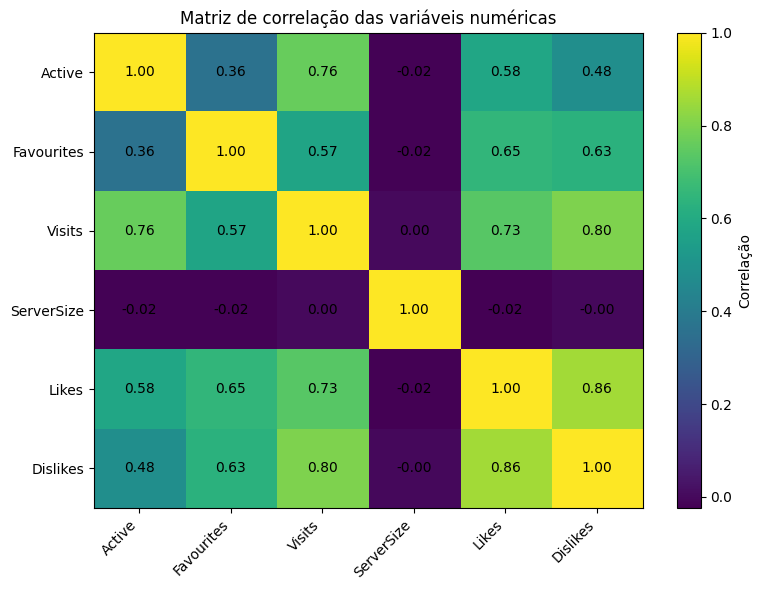

In [695]:
plt.figure(figsize=(8, 6))

corr_matrix_pd = corr_matrix.to_pandas()

plt.imshow(corr_matrix_pd, aspect="auto")
plt.colorbar(label="Correlação")

plt.xticks(
    ticks=np.arange(len(corr_matrix_pd.columns)),
    labels=corr_matrix_pd.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(corr_matrix_pd.index)),
    labels=corr_matrix_pd.index
)

# Escrever os valores dentro da matriz
for i in range(len(corr_matrix_pd.index)):
    for j in range(len(corr_matrix_pd.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix_pd.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

### Distribuições

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning:

`to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.



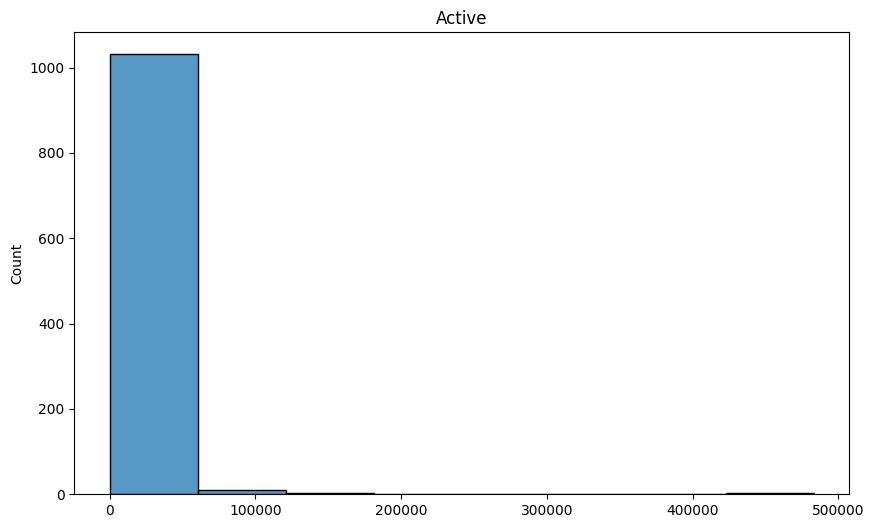

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning:

`to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.



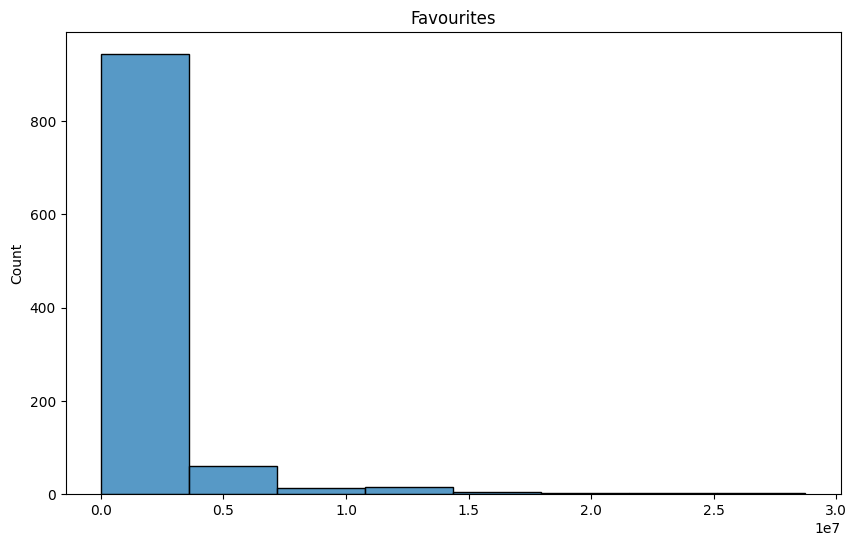

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning:

`to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.



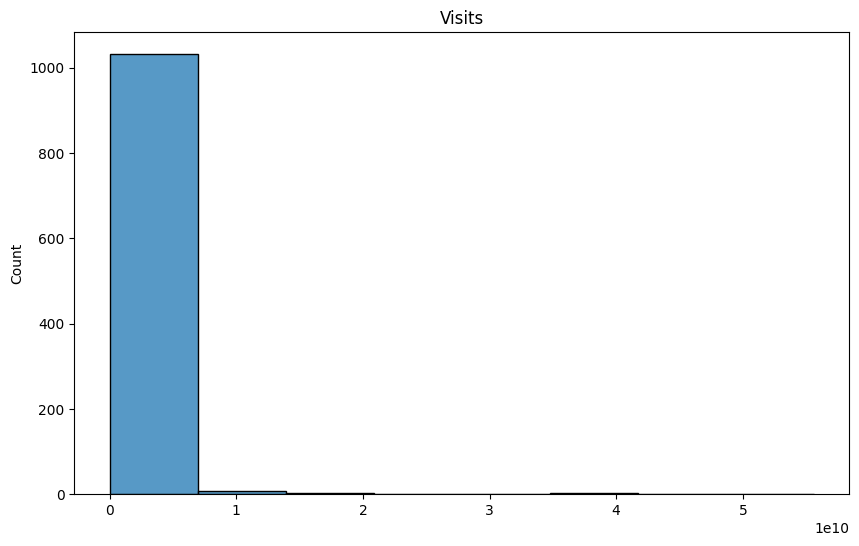

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning:

`to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.



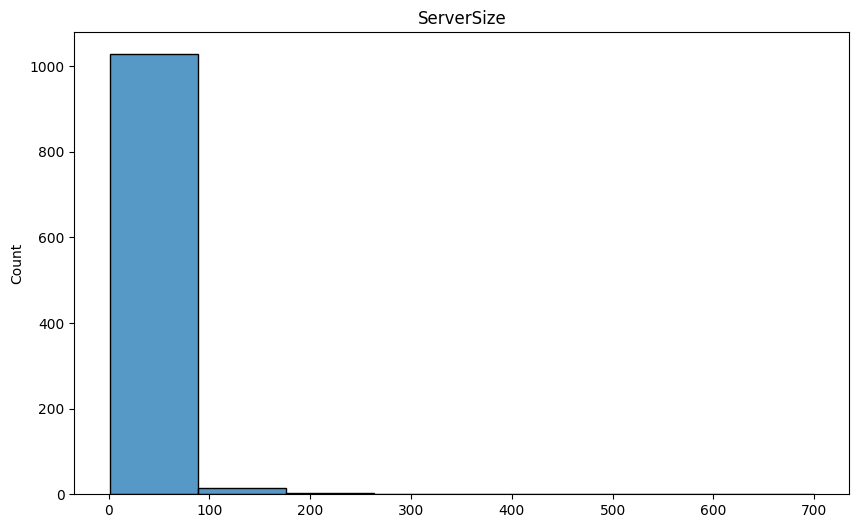

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning:

`to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.



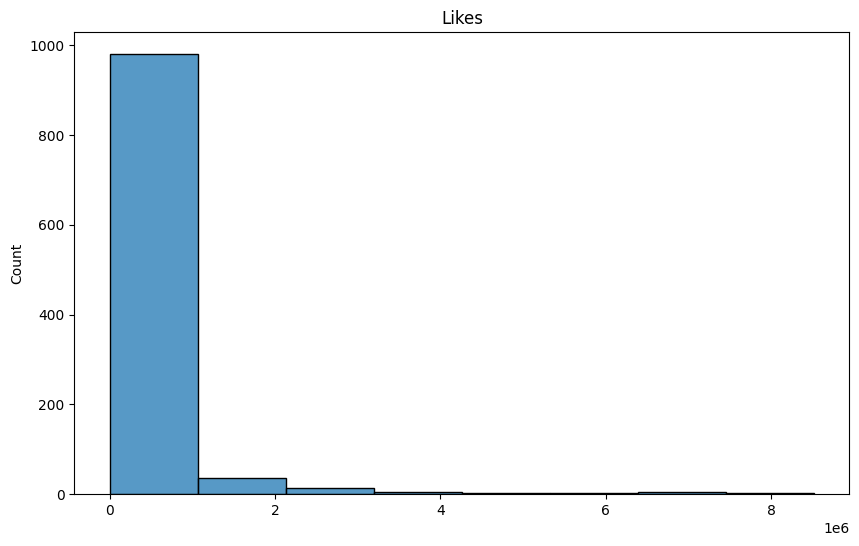

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning:

`to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.



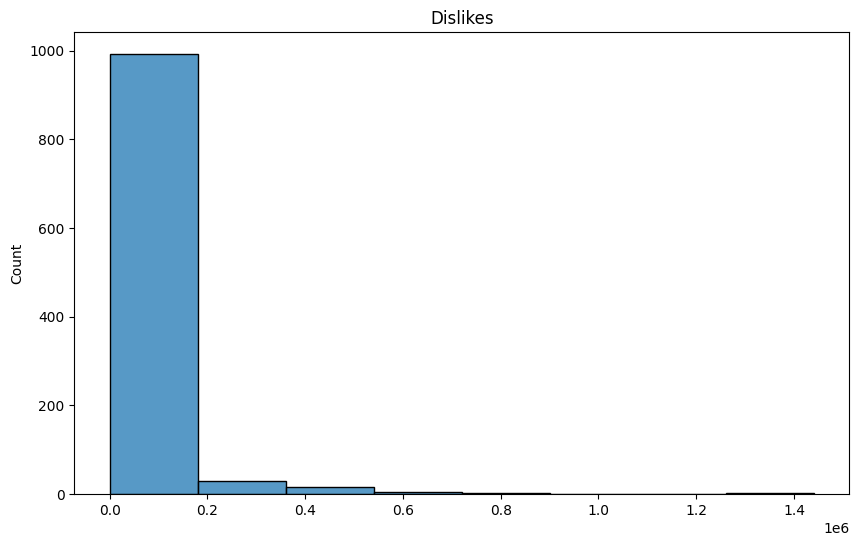

In [696]:

for i in num_cols:
  plt.figure(figsize=(10, 6))
  plt.title(i)
  sns.histplot(df_num[i].to_numpy(), bins=8)
  plt.show()

### Data criação jogos com genero Nan

In [697]:
p_df=df_final.toPandas()

In [698]:
p_df["Created"] = pd.to_datetime(p_df["Created"], errors="coerce")

In [699]:
p_df["Genre"] = p_df["Genre"].replace(
    "N/A",
    np.nan
)

In [700]:
df_genre_nan = p_df[p_df["Genre"].isna()]

In [701]:
df_genre_nan.head()

,Normalized_name,Title,Creator,AgeRecommendation,Active,Favourites,Visits,VoiceChat,Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes,GameLink,DateFetched


In [702]:
df_genre_nan["Created"].describe()

,Created
count,0
mean,NaT
min,NaT
25%,NaT
50%,NaT
75%,NaT
max,NaT


In [703]:
com_genero = p_df[p_df["Genre"].notna()]
com_genero["Created"].describe()

,Created
count,1047
mean,2022-02-05 00:15:07.736389632
min,2008-03-29 00:00:00
25%,2021-01-28 00:00:00
50%,2022-11-19 00:00:00
75%,2023-12-17 12:00:00
max,2024-09-20 00:00:00


In [704]:
sem_genero = p_df[p_df["Genre"].isna()]
com_genero = p_df[p_df["Genre"].notna()]

print("Jogos sem gênero:")
print("Quantidade:", len(sem_genero))
print("Data mínima:", sem_genero["Created"].min())
print("Data média:", sem_genero["Created"].mean())
print("Data mediana:", sem_genero["Created"].median())
print("Data máxima:", sem_genero["Created"].max())

print("\nJogos com gênero:")
print("Quantidade:", len(com_genero))
print("Data mínima:", com_genero["Created"].min())
print("Data média:", com_genero["Created"].mean())
print("Data mediana:", com_genero["Created"].median())
print("Data máxima:", com_genero["Created"].max())

Jogos sem gênero:
Quantidade: 0
Data mínima: NaT
Data média: NaT
Data mediana: NaT
Data máxima: NaT

Jogos com gênero:
Quantidade: 1047
Data mínima: 2008-03-29 00:00:00
Data média: 2022-02-05 00:15:07.736389632
Data mediana: 2022-11-19 00:00:00
Data máxima: 2024-09-20 00:00:00


### Avaliação por genero

In [705]:
genres=p_df["Genre"].unique()

In [706]:
p_df_plot = p_df.copy()
p_df_plot = p_df_plot[p_df_plot["Genre"].notna()]

In [707]:
genres = sorted(p_df_plot["Genre"].dropna().unique())

cmap = plt.get_cmap("tab20")

genre_colors = {
    genre: cmap(i / max(len(genres) - 1, 1))
    for i, genre in enumerate(genres)
}

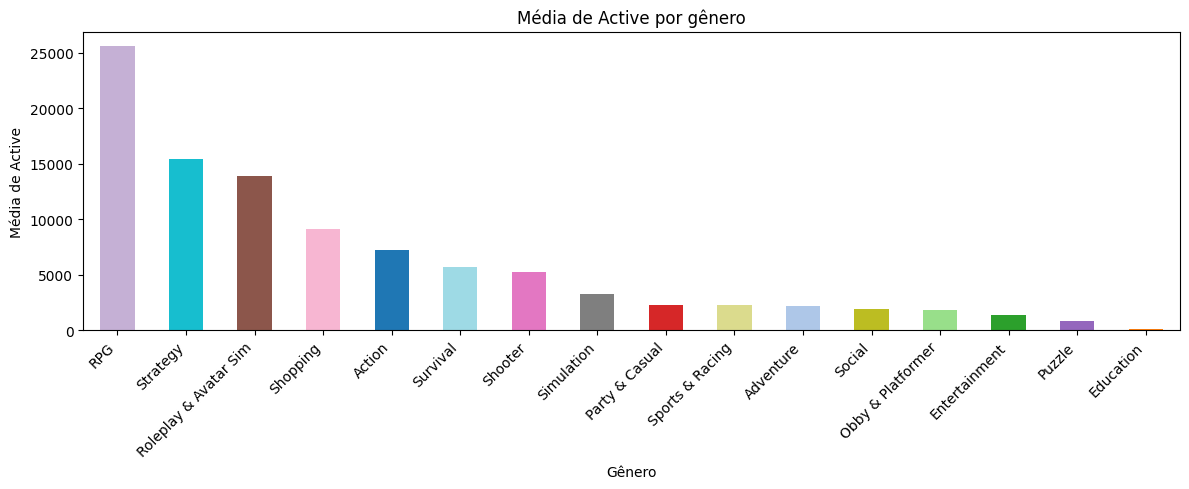

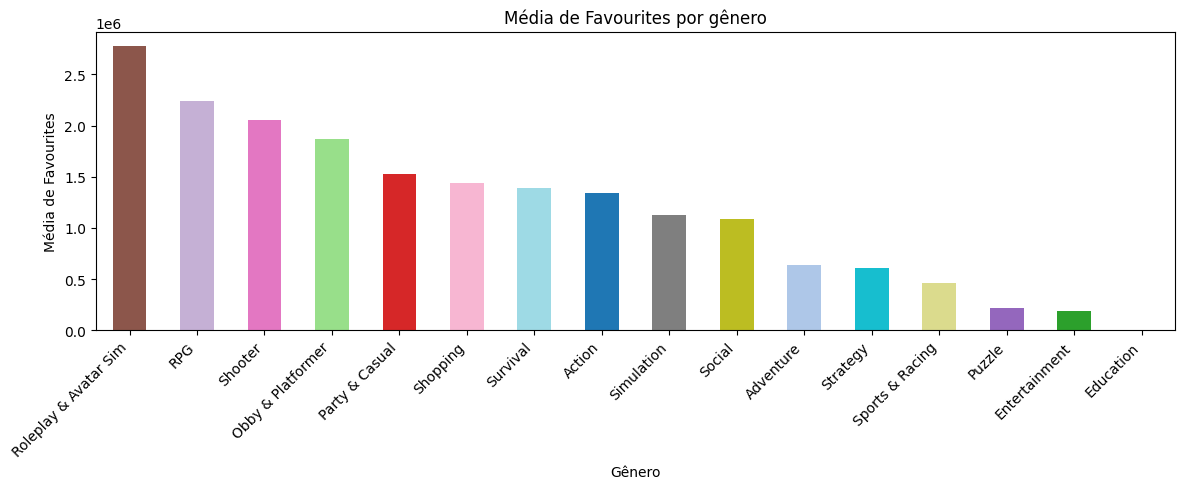

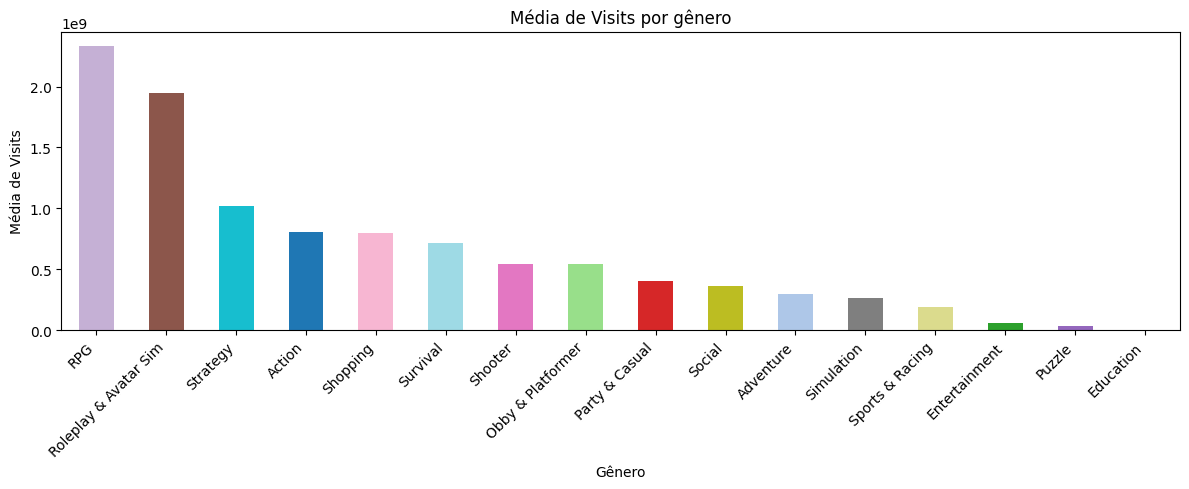

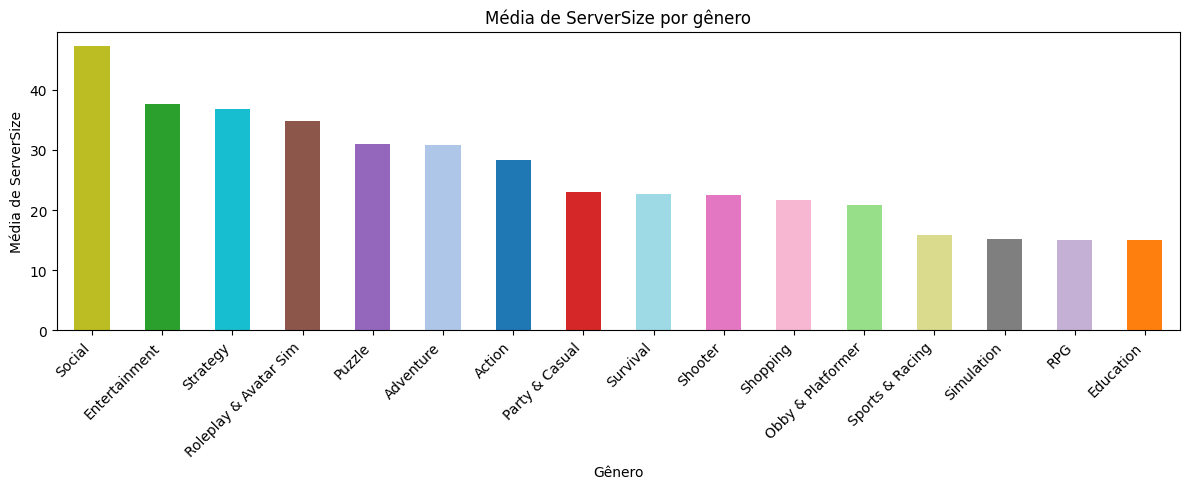

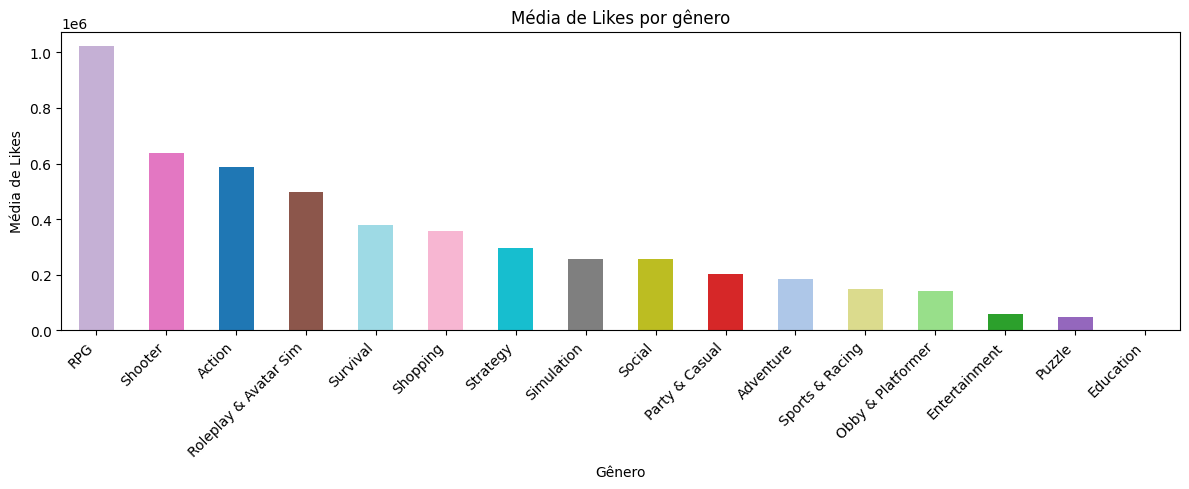

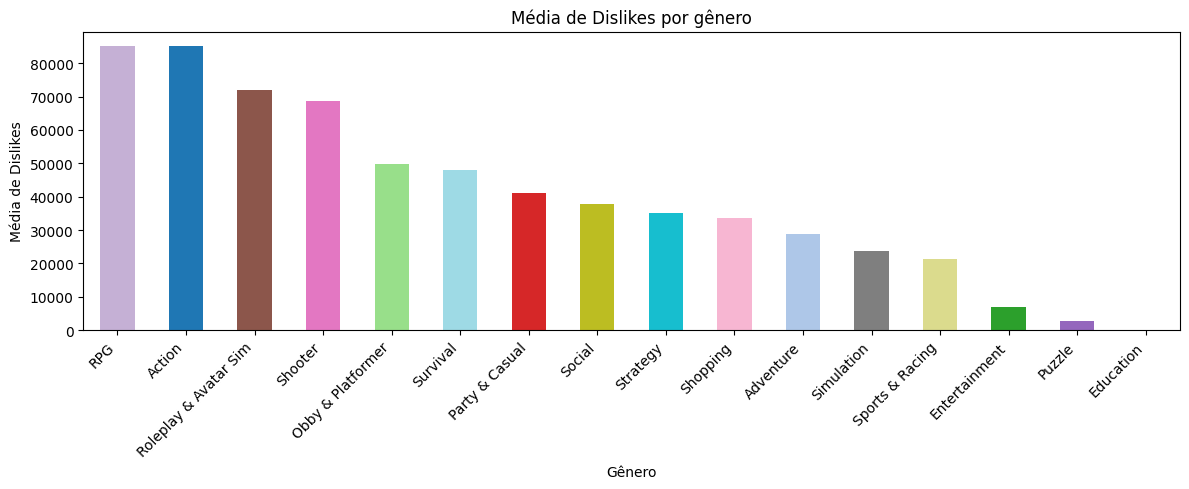

In [708]:
for col in num_cols:
    medias = (
        p_df_plot
        .groupby("Genre")[col]
        .mean()
        .sort_values(ascending=False)
    )

    colors = [genre_colors[genre] for genre in medias.index]

    plt.figure(figsize=(12, 5))
    medias.plot(kind="bar", color=colors)

    plt.title(f"Média de {col} por gênero")
    plt.xlabel("Gênero")
    plt.ylabel(f"Média de {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

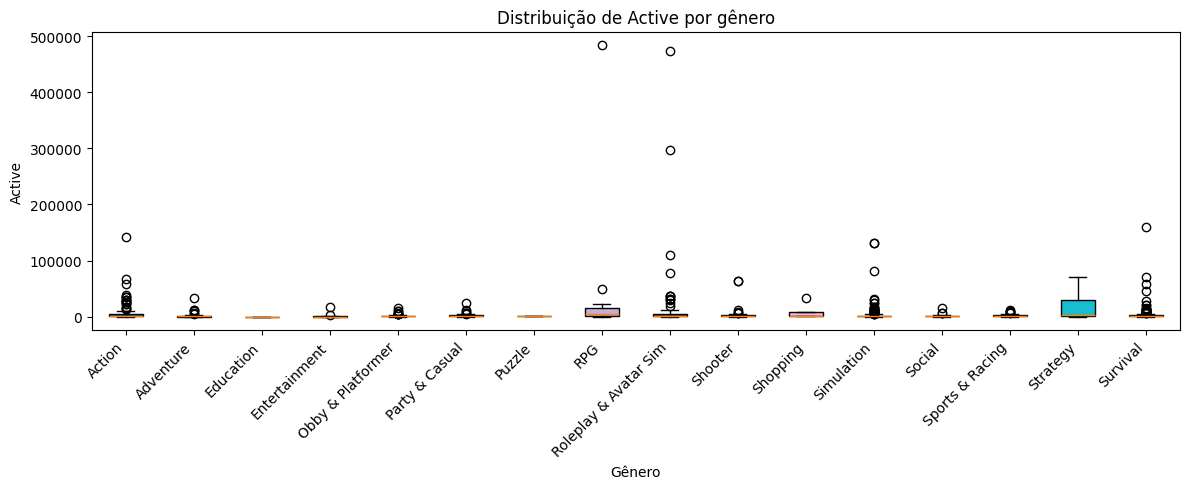

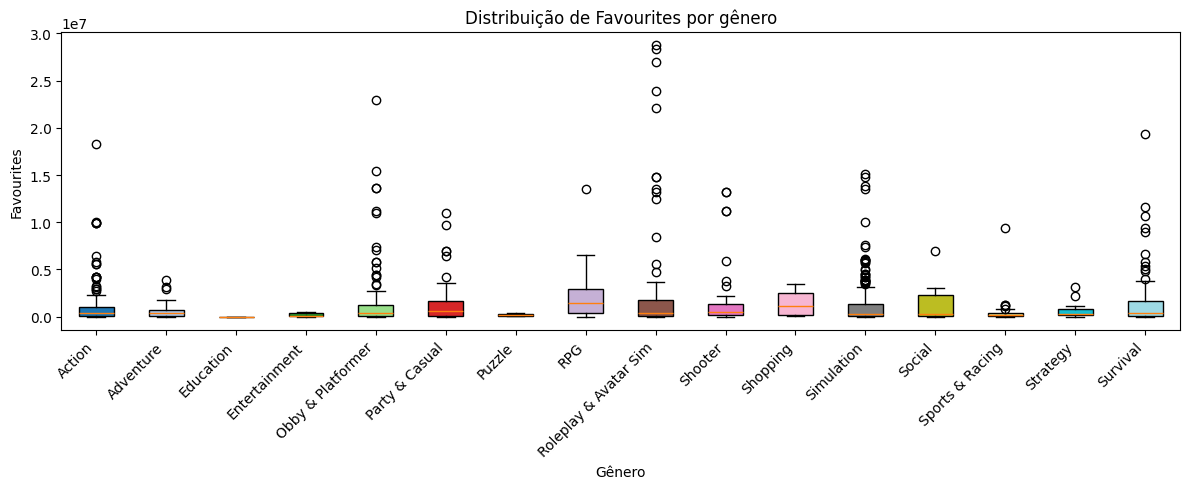

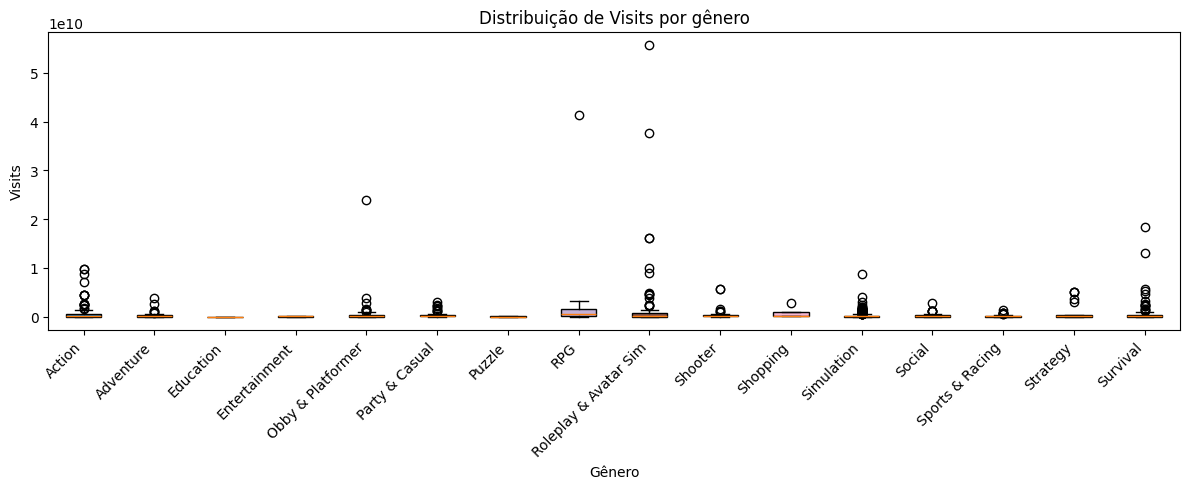

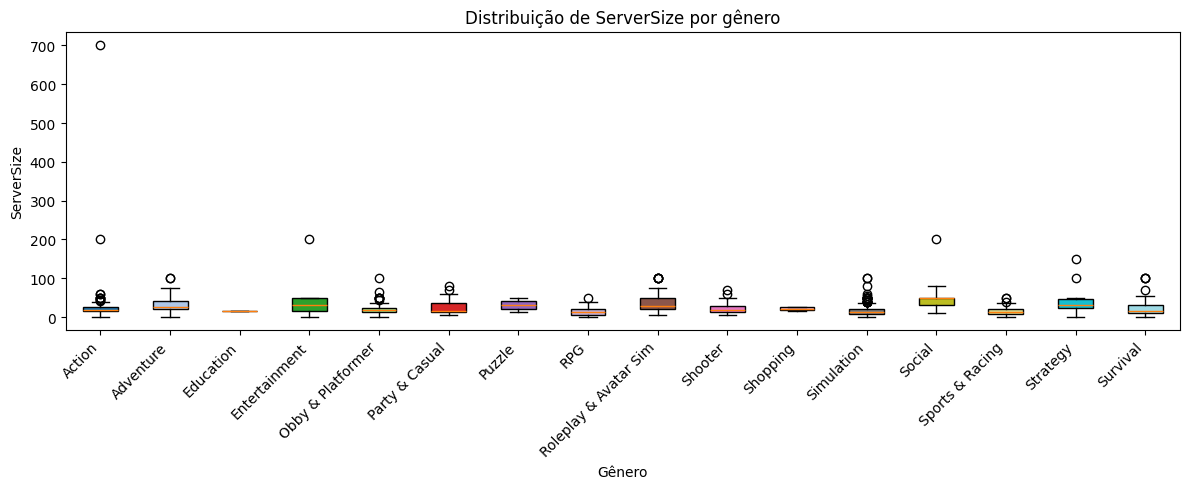

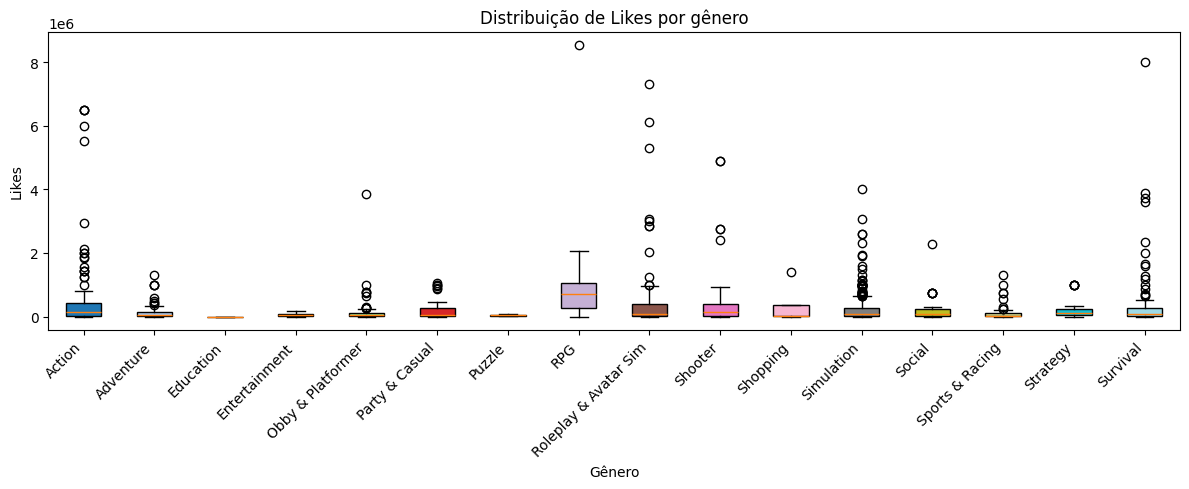

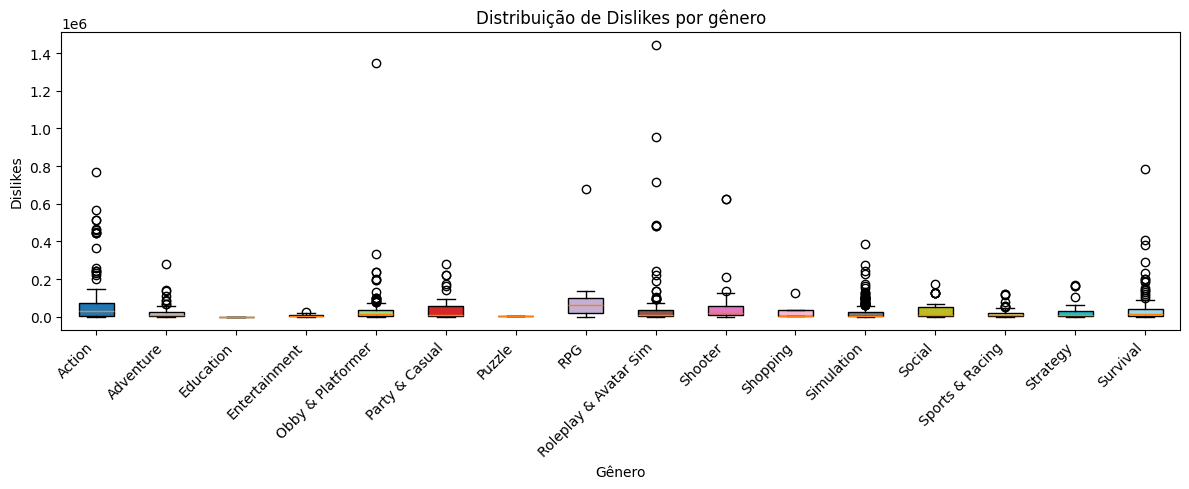

In [709]:
for col in num_cols:
    data = []
    labels = []

    for genre in genres:
        values = p_df_plot.loc[p_df_plot["Genre"] == genre, col].dropna()
        if len(values) > 0:
            data.append(values)
            labels.append(genre)

    plt.figure(figsize=(12, 5))

    box = plt.boxplot(
        data,
        tick_labels=labels,
        patch_artist=True
    )

    for patch, genre in zip(box["boxes"], labels):
        patch.set_facecolor(genre_colors[genre])

    plt.title(f"Distribuição de {col} por gênero")
    plt.xlabel("Gênero")
    plt.ylabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# PCA

### Transformando amostras

In [710]:
from pyspark.sql.functions import log1p, col

df_pca = df_final

cols_log = ["Active", "Visits", "Favourites", "Likes", "Dislikes","ServerSize"]

# Criar versões em log das colunas de contagem
for c in cols_log:
    df_pca = df_pca.withColumn(f"log_{c}", log1p(col(c).cast("double")))



In [711]:
#df_pca=remover_outliers_iqr(df_pca,cols_log,fator=3.0)

In [712]:
features_cols = [f"log_{c}" for c in cols_log]

assembler = VectorAssembler(
    inputCols=features_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

df_vector = assembler.transform(df_pca)

In [713]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

### Aplicação PCA

In [714]:
pca = PCA(
    k=3,
    inputCol="features_scaled",
    outputCol="pca_features"
)

pca_model = pca.fit(df_scaled)
df_pca_result = pca_model.transform(df_scaled)

In [715]:
pca_model.explainedVariance

DenseVector([0.6818, 0.167, 0.0745])

In [716]:
pc_matrix = pca_model.pc.toArray()

loadings = pd.DataFrame(
    pc_matrix,
    index=features_cols,
    columns=[f"PC{i+1}" for i in range(pc_matrix.shape[1])]
)

loadings

,PC1,PC2,PC3
log_Active,-0.391810,0.076051,0.900337
log_Visits,-0.472756,-0.029250,-0.053732
log_Favourites,-0.432278,0.021406,-0.287512
log_Likes,-0.465867,0.035717,-0.179841
log_Dislikes,-0.466857,-0.017822,-0.260021
log_ServerSize,-0.033689,-0.995645,0.062371


In [717]:
# Separar o vetor pca_features em duas colunas: PC1 e PC2
get_pc1 = udf(lambda v: float(v[0]), DoubleType())
get_pc2 = udf(lambda v: float(v[1]), DoubleType())

df_pca_plot = (
    df_pca_result
    .withColumn("PC1", get_pc1(col("pca_features")))
    .withColumn("PC2", get_pc2(col("pca_features")))
    .select("Title", "Genre", "PC1", "PC2")
)

pdf_pca = df_pca_plot.toPandas()

### Plot

In [718]:
fig = px.scatter(
    pdf_pca,
    x="PC1",
    y="PC2",
    color="Genre",
    hover_name="Title",
    hover_data={
        "Genre": True,
        "PC1": ":.2f",
        "PC2": ":.2f"
    },
    title="PCA dos jogos do Roblox por gênero"
)

fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    legend_title="Gênero"
)

fig.show()

In [719]:
plot_pca_spark = (
    df_pca_result
    .withColumn("PC1", get_pc1(col("pca_features")))
    .withColumn("PC2", get_pc2(col("pca_features")))
    .select("Title", "Genre","Active","Visits","Favourites","Likes","Dislikes","ServerSize","PC1","PC2")
)

plot_pca = plot_pca_spark.toPandas()

fig = px.scatter(
    plot_pca,
    x="PC1",
    y="PC2",
    color="Genre",
    hover_name="Title",
    hover_data={
        "Genre": True,
        "Active": True,
        "Visits": True,
        "Favourites": True,
        "Likes": True,
        "Dislikes": True,
        "ServerSize": True,
        "PC1": ":.2f",
        "PC2": ":.2f"
    },
    title="PCA dos jogos do Roblox por gênero"
)

fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    legend_title="Gênero"
)

fig.show()

# Clustering

## K-Means

### Aplicar k-means

In [720]:
evaluator = ClusteringEvaluator(
    featuresCol="features_scaled",
    predictionCol="cluster_kmeans",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

In [721]:
resultados_k = []

for k in range(2, 9):
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="features_scaled",
        predictionCol="cluster_kmeans"
    )

    model = kmeans.fit(df_scaled)
    predictions = model.transform(df_scaled)
    silhouette = evaluator.evaluate(predictions)

    resultados_k.append((k, silhouette))
    print(f"k={k} | silhouette={silhouette:.4f}")

k=2 | silhouette=0.5251
k=3 | silhouette=0.4588
k=4 | silhouette=0.3655
k=5 | silhouette=0.3522
k=6 | silhouette=0.3353
k=7 | silhouette=0.3242
k=8 | silhouette=0.3179


In [722]:
kmeans = KMeans(
    k=2,
    seed=42,
    featuresCol="features_scaled",
    predictionCol="cluster_kmeans"
)



In [723]:
kmeans_model = kmeans.fit(df_scaled)

df_cluster = kmeans_model.transform(df_scaled)

silhouette = evaluator.evaluate(df_cluster)

In [724]:
df_cluster_pca = (
    kmeans_model.transform(df_pca_result)
    .withColumn("PC1", get_pc1(col("pca_features")))
    .withColumn("PC2", get_pc2(col("pca_features")))
    .select(
        "Title",
        "Genre",
        "PC1",
        "PC2",
        "cluster_kmeans",
        "Active",
        "Visits",
        "Likes",
        "Dislikes",
        "Favourites",
        "ServerSize"
    )
)

In [725]:
pdf_cluster_pca = df_cluster_pca.toPandas()

### Plot

In [726]:
pdf_cluster_pca["cluster_kmeans"] = pdf_cluster_pca["cluster_kmeans"].astype(str)

fig = px.scatter(
    pdf_cluster_pca,
    x="PC1",
    y="PC2",
    color="cluster_kmeans",
    hover_name="Title",
    hover_data={
        "Genre": True,
        "Active": True,
        "Visits": True,
        "Likes": True,
        "Dislikes": True,
        "Favourites": True,
        "ServerSize": True,
        "PC1": ":.2f",
        "PC2": ":.2f"
    },
    title="Clusters dos jogos do Roblox visualizados no PCA"
)

fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    legend_title="Cluster"
)

fig.show()

### Analise

In [727]:
pdf_cluster_pca

,Title,Genre,PC1,PC2,cluster_kmeans,Active,Visits,Likes,Dislikes,Favourites,ServerSize
0,Anime Catching Simulator,Simulation,0.098438,0.376280,1,206,79300000,285000,12000,191886,12
1,Gun Armory Tycoon,Simulation,0.928776,0.898465,1,1006,32066588,46677,3736,55544,8
2,Piggy [DECAY CHAPTER],Survival,-4.415422,1.364040,0,27466,13110395425,3615821,406011,11669525,6
3,Roblox Spirit Halloween 2024,Entertainment,5.683558,-1.554759,1,13,417900,348,98,731,50
4,Sol's RNG [Eon1],Simulation,-2.758569,-0.011183,0,81975,778100000,755000,101000,640825,20
...,...,...,...,...,...,...,...,...,...,...,...
1042,🦷 Escape The Dentist! (OBBY!),Obby & Platformer,3.292417,0.198755,1,431,3800000,194,85,477699,14
1043,🧑🏼‍🤝‍🧑🏼Boulder Buddies [2 Player Obby],Obby & Platformer,2.499975,0.025628,1,272,7600000,11000,589,21478,16
1044,🧡 [TAKE IT SLOW +15] SODAH,Social,1.520696,-1.368121,1,524,13900000,13000,2143,84278,50
1045,🩸BLOODstain🩸,Action,3.344658,-0.092124,1,3,3000000,5582,3467,20799,15


In [728]:
pdf_cluster_pca_km0= pdf_cluster_pca[pdf_cluster_pca["cluster_kmeans"]=="0"]
pdf_cluster_pca_km1= pdf_cluster_pca[pdf_cluster_pca["cluster_kmeans"]=="1"]

In [729]:
pdf_cluster_pca_km0.describe()

,PC1,PC2,Active,Visits,Likes,Dislikes,Favourites,ServerSize
count,514.000000,514.000000,514.000000,5.140000e+02,5.140000e+02,5.140000e+02,5.140000e+02,514.000000
mean,-1.622597,-0.052913,10613.107004,1.305020e+09,6.645988e+05,8.723226e+04,2.561537e+06,23.914397
std,1.162077,0.933107,36395.948569,4.039274e+09,1.105221e+06,1.446610e+05,4.027064e+06,18.489670
min,-5.885199,-2.789457,15.000000,1.932654e+07,1.100000e+04,2.760000e+03,6.713400e+04,1.000000
25%,-2.393252,-0.668274,1145.750000,1.652203e+08,1.262822e+05,1.957350e+04,4.651282e+05,12.000000
50%,-1.453791,-0.050118,2385.000000,3.932370e+08,3.009175e+05,3.956550e+04,1.132450e+06,18.500000
75%,-0.707938,0.499390,7103.000000,1.000290e+09,7.455000e+05,9.557575e+04,2.574750e+06,30.000000
max,0.023470,2.973432,483372.000000,5.563515e+10,8.521670e+06,1.441230e+06,2.873764e+07,150.000000


In [730]:
pdf_cluster_pca_km0["Genre"].value_counts()

,count
Genre,
Simulation,128
Action,75
Survival,62
Roleplay & Avatar Sim,54
Obby & Platformer,46
Party & Casual,28
Shooter,23
Adventure,23
RPG,23


In [731]:
pdf_cluster_pca_km1.describe()

,PC1,PC2,Active,Visits,Likes,Dislikes,Favourites,ServerSize
count,533.000000,533.000000,533.000000,5.330000e+02,533.000000,533.000000,5.330000e+02,533.000000
mean,1.564756,0.051027,809.054409,3.348833e+07,31540.196998,5036.913696,3.030820e+05,22.806754
std,1.320845,1.060476,1037.547520,3.821609e+07,39811.106569,6538.358912,7.718258e+05,36.442227
min,-0.044667,-4.967786,0.000000,1.080000e+05,26.000000,29.000000,1.820000e+02,1.000000
25%,0.536145,-0.589957,157.000000,7.429795e+06,5539.000000,1230.000000,2.644700e+04,10.000000
50%,1.206197,0.077371,677.000000,2.067717e+07,19639.000000,3165.000000,7.611100e+04,15.000000
75%,2.156326,0.633558,1061.000000,4.690000e+07,39406.000000,6574.000000,2.085300e+05,25.000000
max,6.844270,2.874312,11027.000000,2.521284e+08,336928.000000,77000.000000,9.341619e+06,700.000000


In [732]:
pdf_cluster_pca_km1["Genre"].value_counts()

,count
Genre,
Simulation,181
Survival,59
Obby & Platformer,50
Roleplay & Avatar Sim,48
Action,46
Adventure,29
Sports & Racing,29
Party & Casual,28
Entertainment,16


## C-Fuzzy

### Código

In [733]:
def generate_random_relevence(X,k,seed=10):

    '''
    Atribui a cada item uma relevância aleatória para cada grupo k.
    Garante que a soma de cada linha seja 1.
    '''

    np.random.seed(seed)
    relevences=[]

    for i in range(len(X)):
        relevences.append([])
        aux=0
        sum=0

        for j in range(k):
            relevences[i].append(np.random.uniform(0,1-aux))
            aux+=relevences[i][j]
            sum+=relevences[i][j]

        if sum!=1:
            relevences[i][0]=1-sum+relevences[i][0]

    return np.array(relevences)


def pertinencias(X, C, m):
    '''
    X: matriz de amostras
    C: matriz de centróides
    m: parâmetro de fuzziness

    Calcula a pertinência w_ij de xi ao centróide C[j]
    usando cdist para calcular as distâncias euclidianas.
    '''

    # cdist é de matrizes 2D, então fiz o reshape xi para (1, n_features)
    # ai da um o array do shape com a distancia de xi pro centroide

    U=[]

    distancias = cdist(X, C, metric='euclidean')

    exponent = 2 / (m - 1)

    for i in distancias:
        aux_U=[]

        for dist_j in i:
            sum = 0

            for dist_l in i:

                if dist_l == 0:
                    sum+=(1.0 if dist_l == dist_j else 0.0)
                else:
                    sum += (dist_j / dist_l)**exponent

            aux_U.append(1 / sum)

        U.append(aux_U)

    return np.array(U)


def centroid_update(X, U, m):

    k = U.shape[1]
    C = []

    for j in range(k):
        numerador = 0
        denominador = 0

        for i in range(len(X)):
            numerador += (U[i][j]) * X[i]
            denominador += U[i][j]

        C.append(numerador/denominador)

    return np.array(C)


def objective_function(X,C,U):

    '''
    X: matriz de dados
    C: matriz de centróides
    U: matriz de pertinência
    Calcula a função objetivo do FCM
    '''

    n_samples = X.shape[0]
    n_clusters = C.shape[0]
    J = 0

    for i in range(n_samples):
        for j in range(n_clusters):
            u_ij = U[i, j]
            J += (u_ij) * (np.linalg.norm(X[i] - C[j]) ** 2)

    return J

In [734]:
def fuzzy_cmeans(X, k, m, max_iter=100, conv = 0.001):

    n_samples = X.shape[0] #n° de linhas

    J_history = []

    U = generate_random_relevence(X, k) #cria a matriz de pertinência aleatória inicial

    C=centroid_update(X, U, m) #inicializa a matriz de centróides

    for iteration in range(max_iter):
        C_old = C.copy()

        U=pertinencias(X, C, m)
        C = centroid_update(X, U, m)
        J = objective_function(X, C, U)


        J_history.append(J)
        convergence = np.linalg.norm(C - C_old)

        #if convergence < conv:
        #    print(f"Convergiu na iteração {iteration}")
        #    break

        labels = np.argmax(U, axis=1)


    return U, C, labels, J_history


### Aplicando

In [735]:
p_df_fcm = df_scaled.select(
    "Title",
    "Genre",
    "features_scaled"
).toPandas()

In [736]:
X_fcm = np.vstack(
    p_df_fcm["features_scaled"].apply(lambda v: v.toArray())
)

In [737]:
U, C, labels, J_history = fuzzy_cmeans(X_fcm,k=2,m=2,)

In [738]:
p_df_fcm["cluster_fuzzy"] = labels
p_df_fcm["max_pertinencia"] = U.max(axis=1)

for i in range(U.shape[1]):
    p_df_fcm[f"pertinencia_cluster_{i}"] = U[:, i]

In [739]:
pdf_fcm_plot = pdf_pca.merge(
    p_df_fcm.drop(columns=["Genre"], errors="ignore"),
    on="Title",
    how="inner"
)

### Plot

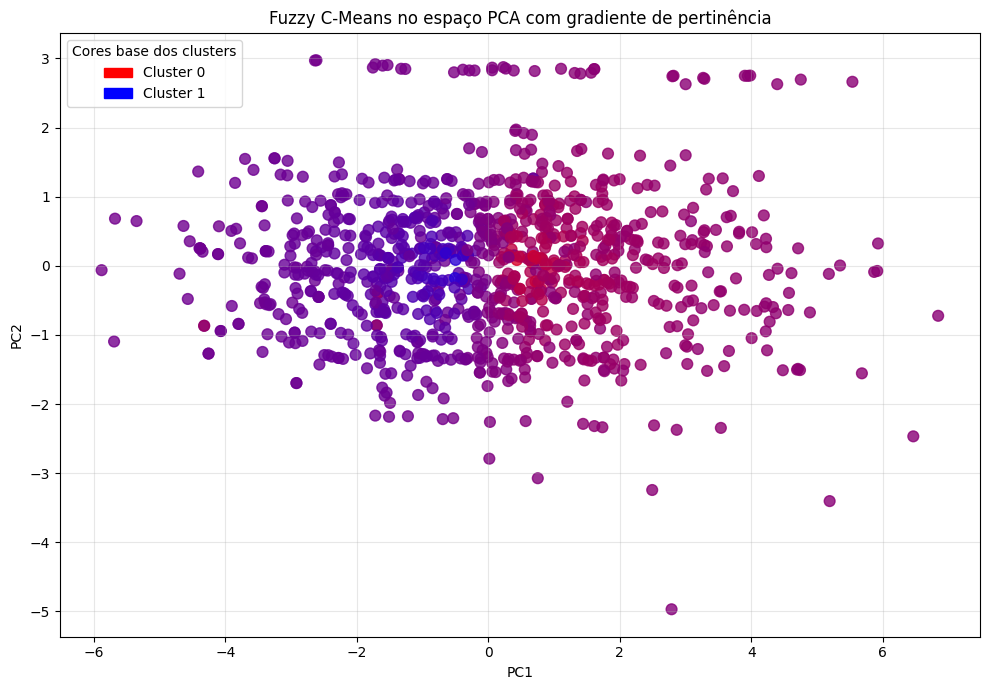

In [740]:
import matplotlib.patches as mpatches

# matriz de pertinências
U_plot = pdf_fcm_plot[
    [
        "pertinencia_cluster_0",
        "pertinencia_cluster_1",

    ]
].values

# cores base dos clusters: vermelho, azul, verde
base_colors = np.array([
    [1.0, 0.0, 0.0],  # cluster 0 -> vermelho
    [0.0, 0.0, 1.0],  # cluster 1 -> azul

])

# mistura ponderada pelas pertinências
point_colors = U_plot @ base_colors

plt.figure(figsize=(10, 7))

plt.scatter(
    pdf_fcm_plot["PC1"],
    pdf_fcm_plot["PC2"],
    c=point_colors,
    s=60,
    alpha=0.8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Fuzzy C-Means no espaço PCA com gradiente de pertinência")

# legenda manual
legend_patches = [
    mpatches.Patch(color=base_colors[0], label="Cluster 0"),
    mpatches.Patch(color=base_colors[1], label="Cluster 1"),

]

plt.legend(handles=legend_patches, title="Cores base dos clusters")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [741]:
pdf_fcm_plot.head()

,Title,Genre,PC1,PC2,features_scaled,cluster_fuzzy,max_pertinencia,pertinencia_cluster_0,pertinencia_cluster_1
0,Anime Catching Simulator,Simulation,0.098438,0.376280,"[-0.9110640835659491, -0.017967783058587733, -...",0,0.509823,0.509823,0.490177
1,Gun Armory Tycoon,Simulation,0.928776,0.898465,"[-0.025175334241826136, -0.44809709108178036, ...",0,0.638122,0.638122,0.361878
2,Piggy [DECAY CHAPTER],Survival,-4.415422,1.364040,"[1.826110615556282, 2.4085952849842345, 1.8010...",1,0.559480,0.440520,0.559480
3,Roblox Spirit Halloween 2024,Entertainment,5.683558,-1.554759,"[-2.4194497564444166, -2.510006415291693, -2.9...",0,0.547290,0.547290,0.452710
4,Sol's RNG [Eon1],Simulation,-2.758569,-0.011183,"[2.4384114257686487, 1.066884297506645, 0.3910...",1,0.576387,0.423613,0.576387
